# Applying a Trajectory-Based Channel in the Frequency and Time Domains

This notebook demonstrates how to apply a **NeoRadium** trajectory-based channel in both the frequency domain and the time domain. It first opens a [DeepMIMO](https://www.deepmimo.net) scenario, creates a random UE trajectory, and then creates a [TrjChannel](https://interdigitalinc.github.io/NeoRadium/html/source/API/Channels.html#neoradium.trjchan.TrjChannel) object from that trajectory.

The notebook then creates a random transmit resource grid and applies the same channel in two different ways:

1. **Frequency-domain channel application:** the channel matrix is obtained from the [TrjChannel](https://interdigitalinc.github.io/NeoRadium/html/source/API/Channels.html#neoradium.trjchan.TrjChannel) object and applied directly to the transmit resource grid.
2. **Time-domain channel application:** the transmit resource grid is first converted to a waveform using OFDM modulation, the trajectory-based channel is applied to the waveform, and the received waveform is synchronized and demodulated back to a resource grid.

Finally, the notebook compares the received resource grids from the two methods using the normalized mean squared error (NMSE).

## Notes

- This simple example applies the channel only at the first point of the trajectory. It does not advance the UE along the trajectory and does not loop over trajectory points.
- No noise is added in this example. The goal is to compare the channel application methods, not to evaluate link performance.
- The NMSE between the frequency-domain and time-domain received grids is expected to be small, but not necessarily exactly zero. The time-domain path includes OFDM modulation, channel filtering, timing synchronization, and OFDM demodulation, which can introduce small numerical differences.
- The trajectory is generated from points on the DeepMIMO grid. The `trajLen` parameter refers to the number of DeepMIMO grid points used for the trajectory, not the final number of interpolated trajectory points.
- The user may need to update the `dataFolder` variable based on the location of the DeepMIMO scenario files on their system.

In [1]:
import numpy as np
import time

from neoradium import DeepMimoData, TrjChannel, BandwidthPart, AntennaPanel, Modem, random
from neoradium.utils import getNmse

In [2]:
# Replace this with the folder on your system where the DeepMIMO scenarios are stored
dataFolder = "/data/RayTracing/DeepMIMO/Scenarios/V4/"
DeepMimoData.setScenariosPath(dataFolder)

# Create a DeepMimoData object
deepMimoData = DeepMimoData("asu_campus_3p5")
deepMimoData.print()


DeepMimoData Properties:
  Scenario:                   asu_campus_3p5
  Version:                    4.0.0a3
  UE Grid:                    rx_grid
  Grid Size:                  411 x 321
  Base Station:               BS (at [166. 104.  22.])
  Total Grid Points:          131,931
  UE Spacing:                 [1. 1.]
  UE bounds (xyMin, xyMax)    [-225.55 -160.17], [184.45 159.83]
  UE Height:                  1.50
  Carrier Frequency:          3.5 GHz
  Num. paths (Min, Avg, Max): 0, 6.21, 10
  Num. total blockage:        46,774
  LOS percentage:             19.71%




Trajectory Properties:
  start (x,y,z):          (-164.55, 69.83, 1.50)
  No. of points:          7,968
  curIdx:                 0 (0.00%)
  curSpeed:               [21.28 21.28  0.  ]
  Total distance:         240.42 meters
  Total time:             7.967 seconds
  Average Speed:          30.177 m/s
  Carrier Frequency:      3.5 GHz
  Paths (Min, Avg, Max):  5, 8.79, 10
  Totally blocked:        0
  LOS percentage:         59.43%



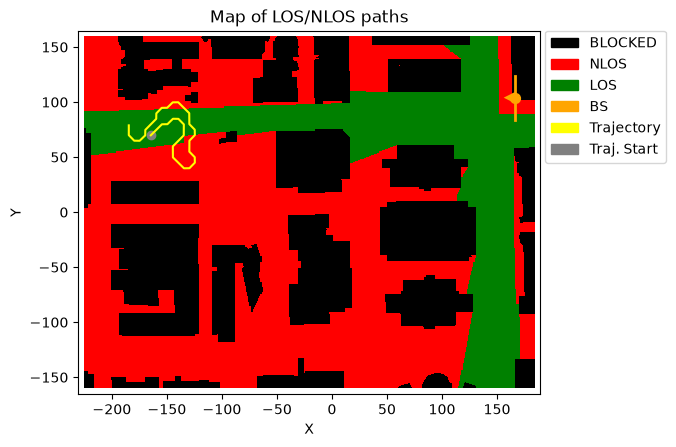

In [3]:
random.setSeed(123)                                 # Make results reproducible
bwp = BandwidthPart(numRbs=24, spacing=15)          # Create a BandwidthPart object

# Create a random trajectory
trajectory = deepMimoData.getRandomTrajectory(xyBounds=np.array([[-210, 40], [-120, 100]]),   # Trajectory bounds
                                              segLen=5,     # Number of DeepMIMO grid points on the shortest segment
                                              bwp=bwp,      # The bandwidth part
                                              trajLen=200,  # Number of DeepMIMO grid points on the trajectory
                                              speedMps=30)  # Speed in m/s

trajectory.print()                                  # Print the trajectory information
ax = deepMimoData.drawMap("LOS-NLOS", trajectory)   # Draw the map with the trajectory
deepMimoData.drawBsPanel(ax, 180)                   # TX antenna at a 180-degree bearing angle

In [4]:
# Print the properties of the first trajectory point
trajectory[0].print()


TrjPoint Properties:
  location:           -164.55   69.83    1.50 m
  Distance to BS:     332.94 m
  LOS/NLOS:           Has LOS path
  numPaths:           8
  sampleNo:           0
  time:               0.000000 sec
  speed vector:       (21.277,21.277,0.000) m/s.
  Line-Of-Sight Path:
    Path ID:          1
    Delay (ns):       1110.94006
    Power (dB):       -93.78190
    Phases (Deg):     -106
    AOA (Deg):        5
    ZOA (Deg):        86
    AOD (Deg):        -174
    ZOD (Deg):        93
  Non-Line-Of-Sight Paths (7):
    Path IDs:         2     3     4     5     6     7     8    
    Delays (ns):      1111. 1111. 1112. 1113. 1113. 1255. 1256.
    Powers (dB):      -97.1 -113. -114. -115. -112. -98.9 -101.
    Phases (Deg):     -39   102   115   -58   162   36    -161 
    AOAs (Deg):       6     3     2     9     -2    -27   -27  
    ZOAs (Deg):       94    94    86    86    85    87    94   
    AODs (Deg):       -174  -173  -172  -178  -172  -151  -151 
    ZODs (Deg)

In [5]:
# Create a random resource grid
txGrid = bwp.createGrid(numPorts=16)                   # Create an empty resource grid

stats = txGrid.getStats()                              # Get statistics about the grid
modem = Modem("16QAM")                                 # Use 16QAM modulation
numRandomBits = stats['UNASSIGNED']*modem.qm           # Total number of bits available in the resource grid

bits = random.bits(numRandomBits)                      # Create random bits
symbols = modem.modulate(bits)                         # Modulate the bits to get symbols

indices = txGrid.getReIndexes("UNASSIGNED")            # Indices of the "UNASSIGNED" resources
txGrid[indices] = symbols                              # Put symbols in the resource grid

txWaveform = txGrid.ofdmModulate()                     # OFDM-modulate the resource grid to get a waveform

print("Resource grid shape:", txGrid.shape)
print("Waveform shape:     ", txWaveform.shape)

Resource grid shape: (16, 14, 288)
Waveform shape:      (16, 30720)


In [6]:
# Create a trajectory-based MIMO channel model
channel = TrjChannel(bwp, trajectory,
                     txAntenna = AntennaPanel([2,4], polarization="x"), # 16 TX antennas
                     txOrientation = [180,0,0],                         # BS antenna facing the left side of the map
                     rxAntenna = AntennaPanel([1,2], polarization="x"), # 4 RX antennas
                     seed=123)
print(channel)


TrjChannel Properties:
  carrierFreq:              3.5 GHz
  normalizeGains:           True
  normalizeOutput:          True
  normalizeDelays:          True
  xPolPower:                10.00 (dB)
  filterLen:                16 samples
  delayQuantSize:           64
  stopBandAtten:            80 dB
  dopplerShift:             353.8 Hz
  coherenceTime:            1.196 milliseconds
  TX Antenna:
    Total Elements:         16
    spacing:                0.5𝜆, 0.5𝜆
    shape:                  2 rows x 4 columns
    polarization:           x
    Orientation (𝛼,𝛃,𝛄):     180° 0° 0°
  RX Antenna:
    Total Elements:         4
    spacing:                0.5𝜆, 0.5𝜆
    shape:                  1 rows x 2 columns
    polarization:           x
  Trajectory:
    start (x,y,z):          (-164.55, 69.83, 1.50)
    No. of points:          7,968
    curIdx:                 0 (0.00%)
    curSpeed:               [21.28 21.28  0.  ]
    Total distance:         240.42 meters
    Total time:           

In [7]:
# Apply the channel in the frequency domain
t0 = time.monotonic()
channelMatrix = channel.getChannelMatrix()
rxGridF = txGrid.applyChannel(channelMatrix)
t1 = time.monotonic()
print(f"Time to apply the channel in the frequency domain (s): {t1-t0:.04f}")

Time to apply the channel in the frequency domain (s): 0.0118


In [8]:
# Apply the channel in the time domain and demodulate the received waveform to get a resource grid
t0 = time.monotonic()
maxDelay = channel.getMaxDelay()                         # Calculate the maximum channel delay
paddedTxWaveform = txWaveform.pad(maxDelay)              # Pad the waveform with zeros
rxWaveform = channel.applyToSignal(paddedTxWaveform)     # Apply the channel to the waveform
offset = channel.getTimingOffset()                       # Get the timing offset for synchronization
syncedWaveform = rxWaveform.sync(offset)                 # Synchronize the received waveform
rxGridT = syncedWaveform.ofdmDemodulate(bwp)             # OFDM-demodulate the synchronized waveform
t1 = time.monotonic()
print(f"Time to apply the channel in the time domain (s): {t1-t0:.04f}")
print(f"NMSE between the rxGrid in time and frequency domains: {getNmse(rxGridT.grid,rxGridF.grid):.04g}") 


Time to apply the channel in the time domain (s): 0.1837
NMSE between the rxGrid in time and frequency domains: 9.404e-18
